In [3]:
import pandas as pd

# Load dataset again in ML notebook
df = pd.read_csv("Crop_recommendation.csv")

print("Dataset loaded successfully")
print(df.head())


Dataset loaded successfully
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [4]:
# Data preparation

# Separate features and target
X = df.drop('label', axis=1)
y = df['label']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeatures used:")
print(X.columns.tolist())

print("\nTarget classes (sample):")
print(y.unique()[:10])


Feature matrix shape: (2200, 7)
Target vector shape: (2200,)

Features used:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

Target classes (sample):
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate']


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling applied successfully.")


Training set shape: (1760, 7) (1760,)
Testing set shape: (440, 7) (440,)

Feature scaling applied successfully.


In [6]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression is a linear classification model
# It works as a strong baseline for multi-class crop prediction
lr_model = LogisticRegression(max_iter=2000, random_state=42)

print("Logistic Regression model initialized.")


Logistic Regression model initialized.


In [7]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree learns decision rules by splitting data based on feature values
# It can capture non-linear relationships in soil and climate data
dt_model = DecisionTreeClassifier(random_state=42)

print("Decision Tree model initialized.")


Decision Tree model initialized.


In [8]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest is an ensemble model using multiple decision trees
# It improves accuracy and reduces overfitting compared to a single tree
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

print("Random Forest model initialized.")


Random Forest model initialized.


In [9]:
from sklearn.naive_bayes import GaussianNB

# Naive Bayes is a probabilistic classifier based on Bayes theorem
# It performs well with numerical features and is computationally efficient
nb_model = GaussianNB()

print("Naive Bayes model initialized.")


Naive Bayes model initialized.


In [10]:
from sklearn.svm import SVC

# Support Vector Machine finds an optimal margin between crop classes
# It is effective for complex, high-dimensional agricultural data
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

print("Support Vector Machine model initialized.")


Support Vector Machine model initialized.


In [13]:
import warnings
warnings.filterwarnings("ignore")


In [14]:
from sklearn.metrics import accuracy_score
import pandas as pd

models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Naive Bayes": nb_model,
    "Support Vector Machine": svm_model
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    results.append({
        "Model": name,
        "Accuracy": acc
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
results_df


,Model,Accuracy
2,Random Forest,0.995455
3,Naive Bayes,0.995455
4,Support Vector Machine,0.984091
1,Decision Tree,0.979545
0,Logistic Regression,0.972727


Classification Report (Random Forest):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.0

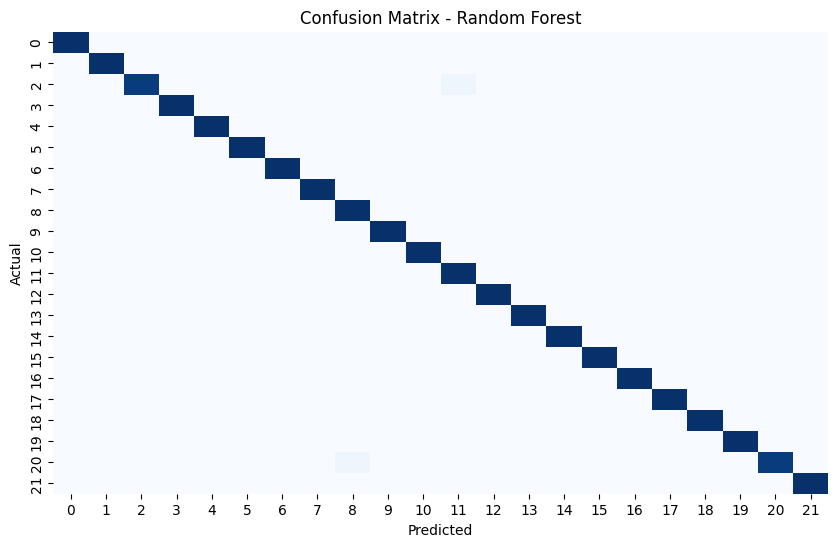

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Use Random Forest as best model
y_pred_best = rf_model.predict(X_test_scaled)

print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_best))

plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test, y_pred_best),
            cmap='Blues',
            cbar=False)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance from Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Display feature importance
feature_importance_df


,Feature,Importance
6,rainfall,0.219641
4,humidity,0.217058
2,K,0.180813
1,P,0.151342
0,N,0.103356
3,temperature,0.075485
5,ph,0.052305


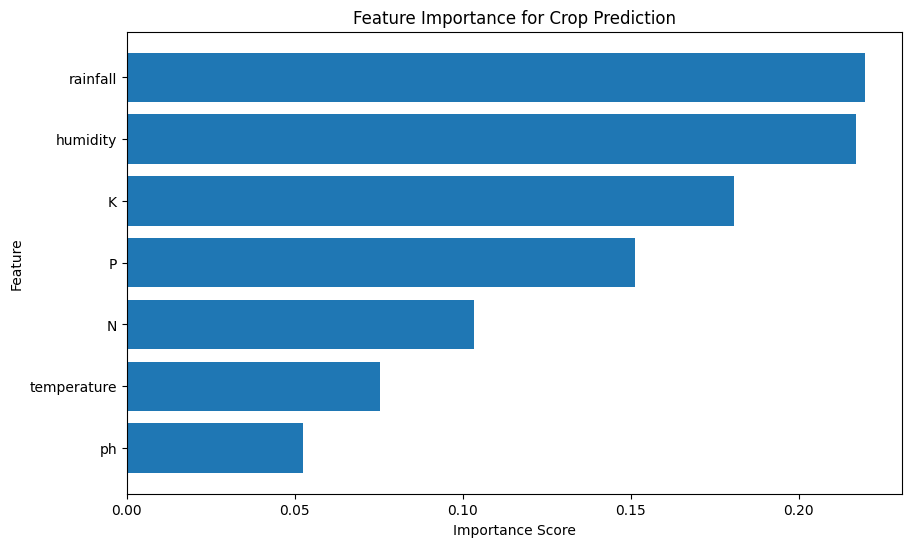

In [18]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance for Crop Prediction")
plt.gca().invert_yaxis()
plt.show()


In [19]:
# Top 3 Crop Recommendation with Confidence Scores
# This step converts the ML model into a decision support system
# Instead of predicting only one crop, it recommends the top 3 most suitable crops

import numpy as np
import pandas as pd

# Use the best performing model (Random Forest)
best_model = models['Random Forest']

def recommend_top_3_crops(input_data):
    """
    Predicts top 3 crops with probability scores
    input_data: numpy array or dataframe with 7 features
    """
    probabilities = best_model.predict_proba(input_data)[0]
    crop_labels = best_model.classes_
    
    results = pd.DataFrame({
        'Crop': crop_labels,
        'Confidence_Score': probabilities
    }).sort_values(by='Confidence_Score', ascending=False)
    
    return results.head(3)

# Example input (sample soil & climate conditions)
sample_input = np.array([[90, 42, 43, 21.5, 80.0, 6.5, 200]])

top_3_crops = recommend_top_3_crops(sample_input)

print("Top 3 Recommended Crops:")
top_3_crops


Top 3 Recommended Crops:


,Crop,Confidence_Score
0,apple,0.470
17,papaya,0.195
7,grapes,0.145


In [21]:
#  Hyperparameter Tuning for Random Forest
# GridSearchCV is used to find the best combination of parameters
# This improves model performance and avoids relying on default settings

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize Random Forest model
rf = RandomForestClassifier(random_state=42)

# Grid Search with 5 fold cross validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train GridSearch
grid_search.fit(X_train_scaled, y_train)

# Best model after tuning
best_rf_model = grid_search.best_estimator_

print("Best Hyperparameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)


Best Hyperparameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross-Validation Accuracy:
0.9960227272727271


In [22]:
# Evaluation of Tuned Random Forest Model

from sklearn.metrics import accuracy_score, classification_report

y_pred_tuned = best_rf_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_tuned)
print("Tuned Random Forest Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))


Tuned Random Forest Accuracy: 0.9954545454545455

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      or

### Conclusion

This project developed an intelligent crop recommendation system using soil nutrients (N, P, K), climatic conditions (temperature, humidity, rainfall), and pH values. Comprehensive exploratory data analysis was performed to understand feature distributions and relationships. Multiple machine learning models — Logistic Regression, Decision Tree, Naive Bayes, Support Vector Machine, and Random Forest — were trained and evaluated, with Random Forest achieving the highest accuracy. Hyperparameter tuning using GridSearchCV further optimized model performance. Finally, the system was enhanced to recommend the top three most suitable crops along with confidence scores, transforming the model into a practical decision-support tool for agricultural planning.